In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot
import matplotlib.patheffects as path_effects

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

import magnus.magnus as magnus
import magnus.oscprob.oscprob as oscprob
import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

First let's define a plotting function for all the cases that we will study:

In [2]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label
    
def make_oscillogram_plot(nu_i, nu_f, H_func, costhz_arr, log10_Enu_arr, 
                          n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3, n_jobs=10, integration_method='trapezoid',
                          validate_input=False, sector_2nu=None, cbar_label_pre='',
                          save_plot=False, path=None, filename=None, format=None):

    heights, widths = [1.0], [1.0]
    gs_kw = dict(height_ratios=heights, width_ratios=widths)
    fig, ax = plt.subplots(
        ncols=1, 
        nrows=1, 
        gridspec_kw=gs_kw, 
        figsize=[9,9])
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    # For 2nu oscillations (i.e., if sector_2nu != None), if the sector is 23, we need to hack the flavor indices
    if sector_2nu == '23':
        if nu_i == gd.NUMU:
            nu_i_ = 0
        elif nu_i == gd.NUTAU:
            nu_i_ = 1
        if nu_f == gd.NUMU:
            nu_f_ = 0
        elif nu_i == gd.NUTAU:
            nu_i_ = 1
    else:
        nu_i_, nu_f_ = nu_i, nu_f
    
    # Generate the probabilities for all combinations of costhz, where prob_arr[i][j] contains the requested probability for nu_i -> nu_f
    # evaluated at Enu_arr[i] and costhz_arr[j]:
    prob_arr = np.array([[oscprob.osc_prob(lambda l: H_func(costhz_arr[j], l, Enu_arr[i]*gd.UNIT_GEV),
                                           0, l_max_arr[j]*gd.CONV_KM_TO_INV_EV, 
                                           n_slabs=n_slabs, n_tpts_per_slab=n_tpts_per_slab, 
                                           magnus_exp_order=magnus_exp_order, n_jobs=n_jobs,
                                           validate_input=validate_input)[nu_i_][nu_f_] 
                  for j in range(costhz_npts)] for i in range(Enu_npts)])

    # Plot
    cs = ax.contourf(costhz_arr, log10_Enu_arr, prob_arr, levels=120, cmap=mpl.cm.plasma) #120
    cbar = fig.colorbar(cs)
    cbar.ax.tick_params(labelsize=25) 
    cbar.set_label(label=cbar_label_pre + prob_label(nu_i, nu_f), fontsize=25)

    # Annotations
    if (sector_2nu == '23'):
        sector_2nu_label = r' (23 sector)'
    elif (sector_2nu == '12'):
        sector_2nu_label = r' (12 sector)'
    else:
        sector_2nu_label = ''
    text = fig.text(0.96, 0.95, prob_label(nu_i, nu_f)+sector_2nu_label,  ha='right', va='center', size=23, color='k', rotation=0.,
                   transform=ax.transAxes)
    text.set_path_effects([path_effects.Stroke(linewidth=12, foreground='white'), path_effects.Normal()])

    # Formatting
    ax.set_xlim([costhz_min, costhz_max])
    ax.set_ylim([log10_Enu_min, log10_Enu_max])
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.02))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.02))
    ax.set_xlabel(r'Zenith angle, $\cos(\theta_z)$')
    ax.set_ylabel(r'Neutrino energy, $\log_{10}(E_\nu/{\rm GeV})$')

    if save_plot:
        plt.savefig(path+filename+'.'+format, bbox_inches='tight', dpi=200)

    return prob_arr

Define the ranges of zenith angle (and, therefore, baseline) and neutrino energies

In [19]:
# Cosines of zenith angles
costhz_min, costhz_max, costhz_npts = -1.0, 0, 150 #100 
costhz_arr = np.linspace(costhz_min, costhz_max, costhz_npts) 

# Baselines, L [km]
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] 

# Neutrino energies [GeV]
log10_Enu_min, log10_Enu_max, Enu_npts = 0.0, 1.0, 150 #100
Enu_arr = np.logspace(log10_Enu_min, log10_Enu_max, Enu_npts)
log10_Enu_arr = np.log10(Enu_arr)

Define the coherent forward potential inside the Earth according to the PREM matter density model.

Because of numerical errors, sometimes `r` can be slightly larger han the Earth's radius, `gd.EARTH_RADIUS`.  The parameter `tol` defines how much larger than 1 the quantity `r-gd.EARTH_RADIUS` can be inside the `earth.density_matter_func_prem`function.  We have set `tol = 1.e-15` manually below because it leads to successful results in our runs, but the user is advised to change its value if their code fails.



In [3]:
# r is the radius from the center of the Earth [km].  

def density_matter_func_prem_wrapper(r):
    return earth.density_matter_func_prem(r, tol=1.e-15)
    
def VCC_func_prem(r):
    return matter.VCC_func(r, lambda rr : matter.num_density_e_func(rr, density_matter_func_prem_wrapper, 
                                                                    ratio_number_neutrons_to_protons=1.0, electron_fraction=0.5)) # [eV]

Generate and plot the $2\nu$ oscillograms.  Let's consider the 2-3 sector, which describes mixing between $\nu_\mu$ and $\nu_\tau$. First, we define the Hamiltonians:

In [27]:
# # Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S23_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_2nu_23_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # [eV^2]

# Matter Hamiltonian
def H_2nu_23_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_2nu_23_energy_indep + hamiltonians2nu.hamiltonian_2nu_matter(VCC_func_prem(r)) # [eV]

Now plot the oscillogram; the probabilities are computed inside the `make_oscillogram_plot` function:

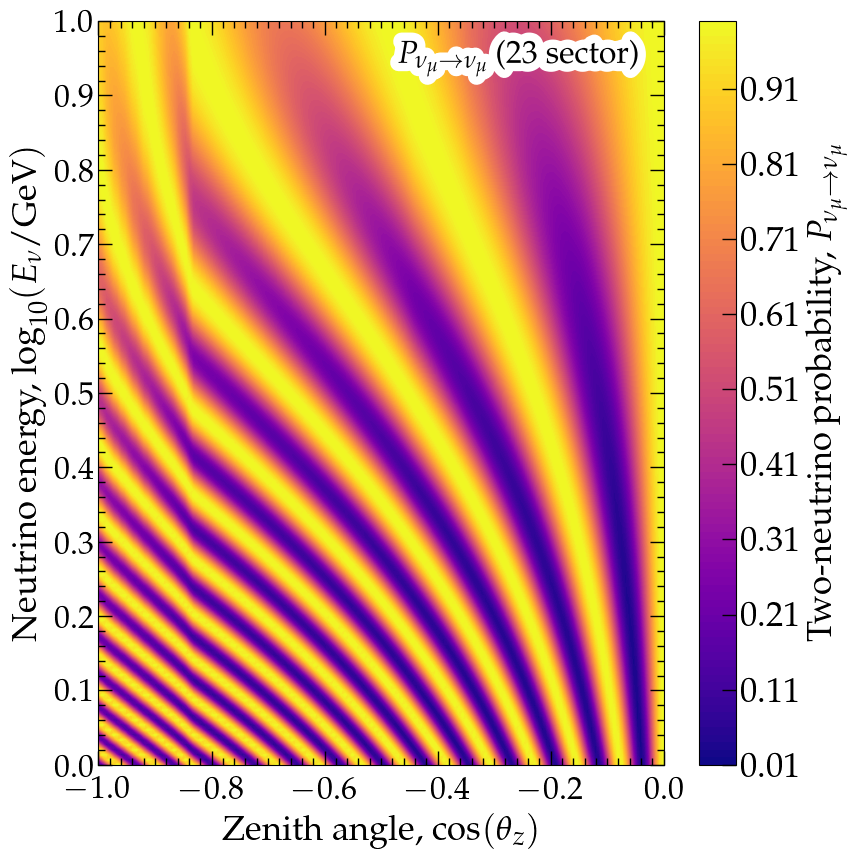

In [28]:
make_oscillogram_plot(gd.NUMU, gd.NUMU, H_2nu_23_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=1, n_tpts_per_slab=100, magnus_exp_order=1, n_jobs=1, integration_method='trapezoid', validate_input=False,
                      sector_2nu='23', cbar_label_pre=r'Two-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

The effect of the core-mantle transition in the density is clearly visible around $\cos \theta_z = -0.85$, as expected.

Of note, in the $2\nu$ case we already obtain the oscillograms that we expected by using a single slab (`n_slabs = 1`) and the lowest order of the Magnus expansion (`magnus_exp_order = 1`), which is equivalent to assuming a time-independent Hamiltonian, or an average matter density along each chord inside the Earth.  

Now we can do the same for the 1-2 sector, starting with defining a new Hamiltonian with the mixing parameters of that sector:

In [29]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_2nu_12_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # [eV^2]

# Matter Hamiltonian
def H_2nu_12_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_2nu_12_energy_indep + hamiltonians2nu.hamiltonian_2nu_matter(VCC_func_prem(r)) # [eV]

And then plot:

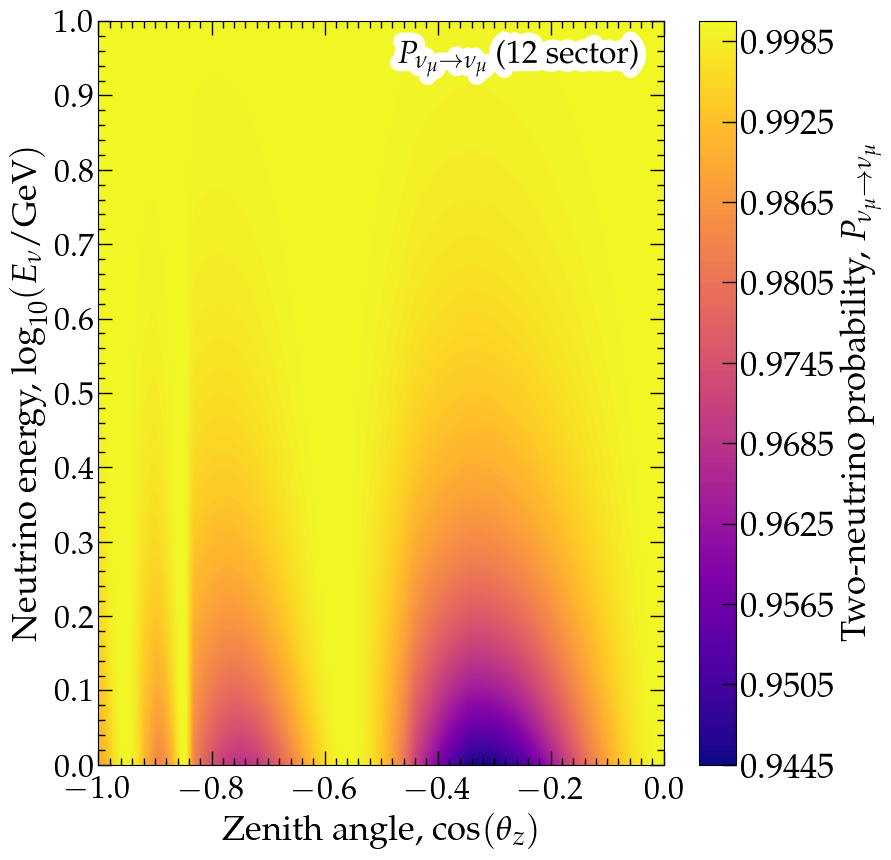

In [30]:
make_oscillogram_plot(gd.NUMU, gd.NUMU, H_2nu_12_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=1, n_tpts_per_slab=100, magnus_exp_order=1, n_jobs=1, integration_method='trapezoid', validate_input=False,
                      sector_2nu='12', cbar_label_pre=r'Two-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

Finally, let's do the same for $3\nu$ oscillations.  First, define the Hamiltonians:

In [16]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_3nu_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31) # [eV^2]

# Matter Hamiltonian
def H_3nu_func_prem(costhz, l, energy):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_3nu_energy_indep + hamiltonians3nu.hamiltonian_3nu_matter(VCC_func_prem(r)) # [eV]

And then plot:

In [17]:
def density_matter_func_prem_wrapper(r):
    return earth.density_matter_func_prem(r, tol=1.e-15)
    
def VCC_func_prem(r):
    return matter.VCC_func(r, lambda rr : matter.num_density_e_func(rr, density_matter_func_prem_wrapper, 
                                                                    ratio_number_neutrons_to_protons=1.0, electron_fraction=0.5)) # [eV]

Let's first generate the oscillogram for the same simplest settings that we used in the $2\nu$ case (`n_slabs = 1`) and (`magnus_exp_order = 1`).

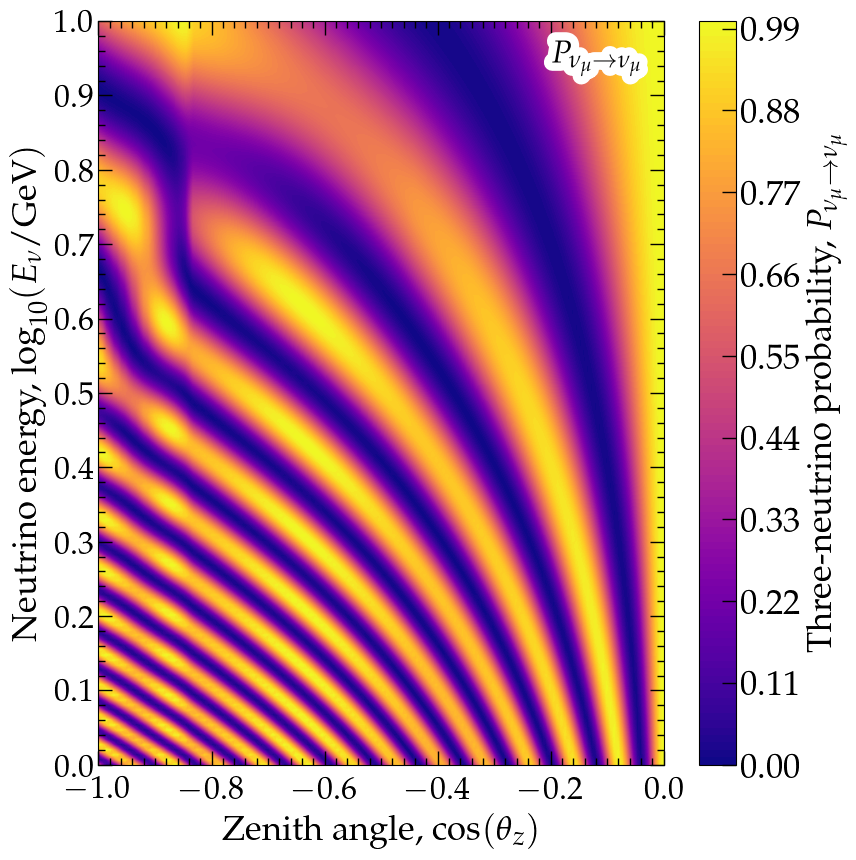

In [22]:
prob_arr_3nu_order_1 = make_oscillogram_plot(gd.NUMU, gd.NUMU, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                                             n_slabs=1, n_tpts_per_slab=100, magnus_exp_order=1, n_jobs=1,
                                             integration_method='trapezoid', validate_input=False,
                                             sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, 
                                             path=None, filename=None, format=None)

This already looks like it should, including showing the transition from core to mantle.  But the fine details are not quite there yet.  

Let's increase the number of slabs used to `n_slabs = 10` and use third-order Magnus expansion instead (`magnus_exp_order = 3`).  We can now set `n_jobs` to > 1 to compute evolution operators on each slab in parallel.

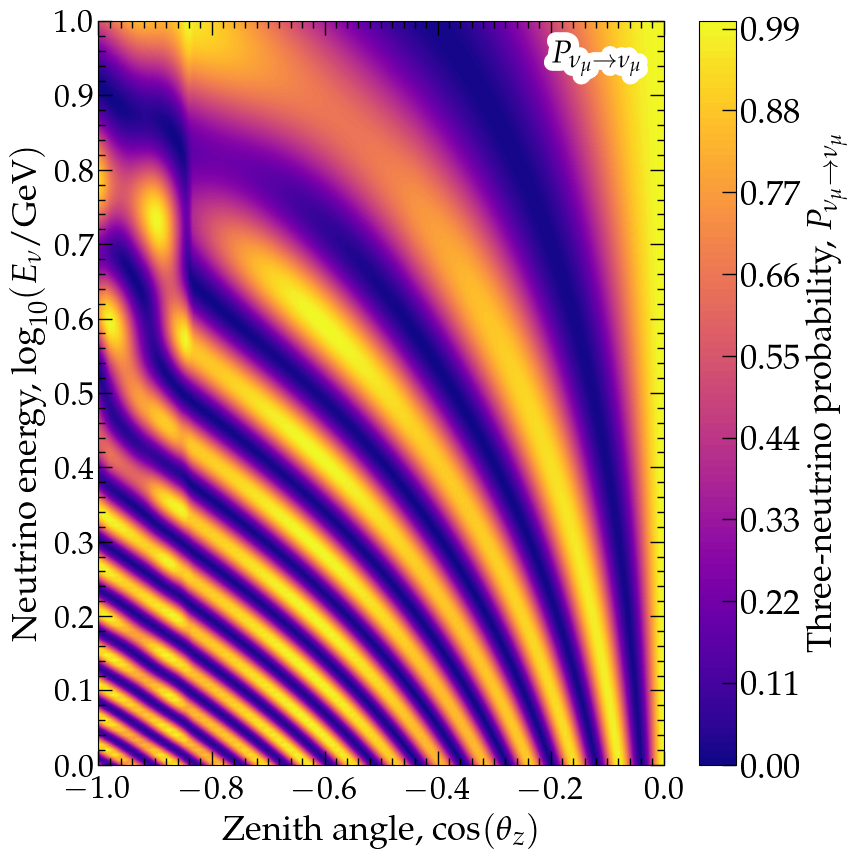

In [25]:
make_oscillogram_plot(gd.NUMU, gd.NUMU, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=10, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=5, integration_method='trapezoid', validate_input=False,
                      sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

If one would like to check whether this result is final or near-final, they can increase the `n_slabs` (or`n_tpts_per_slab`, or `magnus_exp_order`) and compare the resulting oscillogram with the one above.

We can also plot oscillograms for other probabilities:

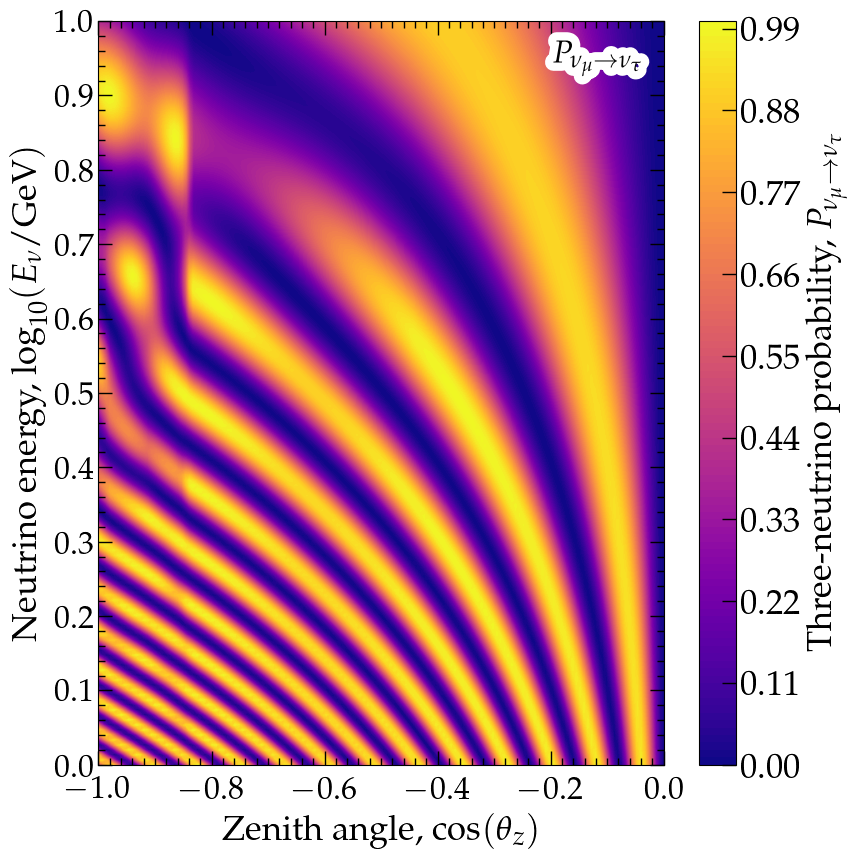

In [31]:
make_oscillogram_plot(gd.NUMU, gd.NUTAU, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=10, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=5, integration_method='trapezoid', validate_input=False,
                      sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

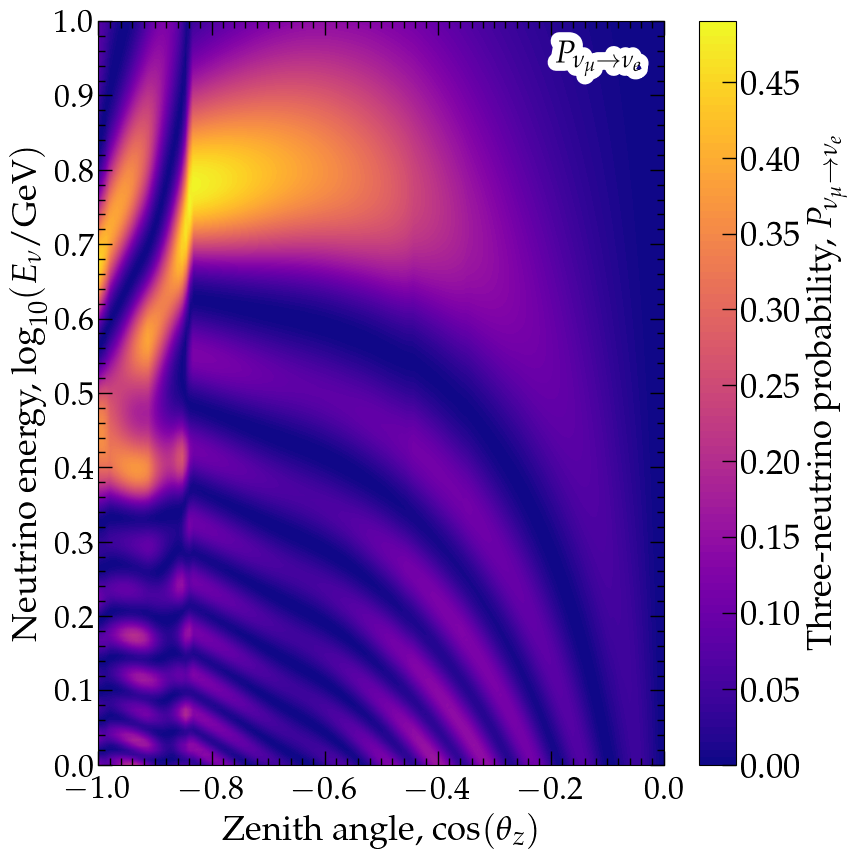

In [32]:
make_oscillogram_plot(gd.NUMU, gd.NUE, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=10, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=5, integration_method='trapezoid', validate_input=False,
                      sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)